In [55]:
import polars as pl
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from linearmodels.iv import compare
from linearmodels.panel.results import compare
import statsmodels.api as sm
from statsmodels.api import qqplot
from linearmodels.panel import PanelOLS
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats as scipy_stats

import pyreadstat as prs
import pygwalker as pyg

import altair as alt
import seaborn as sns
import matplotlib.pyplot as plt

import json

from tqdm.notebook import tqdm
from itables import init_notebook_mode
# init_notebook_mode()

In [3]:
book_colors = {
    'primary': '#2E86AB',    # Steel blue - main data
    'secondary': '#A23B72',  # Magenta - secondary data
    'accent': '#F18F01',     # Orangxe - highlights/warnings
    'success': '#C73E1D',    # Red-orange - thresholds/targets
    'muted': '#6C757D',      # Gray - reference lines
    'light_gray': '#E5E5E5', # Light gray - backgrounds
    'dark_gray': '#4D4D4D'   # Dark gray - text
}

def setup_book_style():
    """Apply consistent styling to matplotlib plots"""
    plt.rcParams.update({
        'figure.figsize': (10, 7),
        'figure.dpi': 100,
        'font.size': 12,
        'axes.titlesize': 16,
        'axes.titleweight': 'bold',
        'axes.labelsize': 14,
        'axes.labelcolor': '#4D4D4D',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.color': '#E5E5E5',
        'legend.fontsize': 11,
        'legend.frameon': False,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
    })

setup_book_style()

In [4]:
def plot_event_margins(model, measure_unit = 'RUB'):
    coef_names = [col for col in model.params.index if col.startswith('rel_period')]
    coefs = model.params[coef_names]
    std_errors = model.std_errors[coef_names]
    
    # Parse relative periods from coefficient names
    rel_periods = [int(name.split('_')[2]) for name in coef_names]
    
    # Create DataFrame for plotting
    coef_df = pd.DataFrame({
        'relative_period': rel_periods,
        'estimate': coefs.values,
        'std_error': std_errors.values
    })
    
    # Add reference period (k = -1) with zero effect
    ref_row = pd.DataFrame({
        'relative_period': [-1],
        'estimate': [0],
        'std_error': [0]
    })
    coef_df = pd.concat([coef_df, ref_row], ignore_index=True)
    coef_df = coef_df.sort_values('relative_period').reset_index(drop=True)
    
    # Calculate confidence intervals (95%)
    coef_df['ci_lower'] = coef_df['estimate'] - 1.96 * coef_df['std_error']
    coef_df['ci_upper'] = coef_df['estimate'] + 1.96 * coef_df['std_error']
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Shade pre-treatment region
    ax.axvspan(-6.5, -0.5, alpha=0.15, color=book_colors['light_gray'], zorder=0)
    
    # Reference lines
    ax.axhline(y=0, linestyle='--', color=book_colors['muted'], linewidth=1, alpha=0.8)
    ax.axvline(x=-0.5, linestyle='--', color=book_colors['muted'], linewidth=1, alpha=0.8)

    ax.axvline(x=-1, linestyle='--', color='red', linewidth=1, alpha=0.8)
    ax.axvline(x=1, linestyle='--', color='red', linewidth=1, alpha=0.8)

    # ax.annotate('pandemic restrictions\nperiod of interest',
    #             xy=(0, coef_df['ci_upper'].min() * 0.5),
    #             fontsize=10, color='red', ha='center', style='italic')
    
    # Error bars
    ax.errorbar(
        coef_df['relative_period'],
        coef_df['estimate'],
        yerr=[coef_df['estimate'] - coef_df['ci_lower'],
              coef_df['ci_upper'] - coef_df['estimate']],
        fmt='o',
        color=book_colors['primary'],
        markersize=8,
        capsize=4,
        capthick=1.5,
        linewidth=1.5,
        ecolor=book_colors['primary'],
        zorder=3
    )
    
    # Annotations
    ax.annotate('Pre-pandemic',
                xy=(-3.5, coef_df['ci_upper'].max() * 0.6),
                fontsize=10, color=book_colors['muted'], ha='center', style='italic')
    
    ax.annotate('Post-pandemic',
                xy=(2.5, coef_df['ci_upper'].max() * 0.95),
                fontsize=10, color=book_colors['primary'], ha='center', style='italic')
    
    # Labels and title
    ax.set_xlabel('Periods', fontsize=14, color=book_colors['dark_gray'])
    ax.set_ylabel(f'Estimated effect ({measure_unit})', fontsize=14, color=book_colors['dark_gray'])
    ax.set_title('Effect of covid-19 restrictions on NEI',
                 fontsize=16, fontweight='bold', color='#333333', pad=15)
    
    # Subtitle
    ax.text(0.5, 1.02, 'Reference period: k = -1 (one period before treatment)',
            transform=ax.transAxes, fontsize=11, color='grey', ha='center')
    
    # Caption (takeaway)
    fig.text(0.1, -0.02,
             'Takeaway: No significant pre-trends; effect peaks at k=1, then gradually declines.',
             fontsize=9, color='grey', ha='left')
    
    ax.set_xticks(range(-6, 4))
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)
    plt.show()

In [5]:
def wald_test_for_period_insignificance(event_study_model_reduced):
    pre_treatment_terms = [t for t in event_study_terms if int(t.split('_')[2]) < -1]
    pre_coefs = event_study_model_reduced.params[pre_treatment_terms].values
    pre_vcov = event_study_model_reduced.cov.loc[pre_treatment_terms, pre_treatment_terms].values

    q = len(pre_treatment_terms)
    wald_stat = pre_coefs @ np.linalg.inv(pre_vcov) @ pre_coefs / q
    df_resid = event_study_model_reduced.nobs - event_study_model_reduced.params.shape[0]
    p_value = 1 - scipy_stats.f.cdf(wald_stat, q, df_resid)
    
    print(f"\nJoint F-test for pre-treatment coefficients:")
    print(f"  F({q}, {df_resid}) = {wald_stat:.4f}")
    print(f"  p-value = {p_value:.4f}")

In [21]:
def visualize(var):
    return (
    panel
        #.filter((pl.col('is_employed_no_disablity') == 1)|(pl.col('is_employed_has_disablity') == 1))
        #.filter(pl.col('h7_2').is_in(['October', 'November', 'December']))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['year', 'has_disablity']).agg(pl.col(var).mean())
).plot.line(x='year', y=var, color='has_disablity')

In [56]:
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                       for i in range(X.shape[1])]
    return vif_data

# goals
* income model
* wages model
* benefit model
* psm ++ all above with psm

In [210]:
panel = pl.read_parquet('../data/wages_working_data.parquet')
panel = panel.filter(
    pl.col('total_income') < 100_000
)
panel = (
    panel
    .with_columns(gender = pl.when(pl.col('gender') == 'MALE').then(1).otherwise(0))
    .with_columns(recieves_pension = pl.when(pl.col('recieves_pension') == 'Yes').then(1).otherwise(0))
    .with_columns(recieves_pension_30days = pl.when(pl.col('recieves_pension_30days') == 'Yes').then(1).otherwise(0))
    .with_columns(income_decrease_bc_covid = pl.when(pl.col('income_decrease_bc_covid') == 'Yes').then(1).otherwise(0))
    .with_columns(pl.col('disability_class').str.replace(' ', '_').str.to_lowercase())
    .to_dummies('disability_class', drop_nulls=True, drop_first=True)
    .with_columns(has_disability = pl.when(pl.col('has_disability') == 'Yes').then(1).otherwise(0))
    .with_columns(male_retiered = pl.when(
        (pl.col('gender') == 1) & (pl.col('age') >= 65)
    ).then(1).otherwise(0))
    .with_columns(female_retiered = pl.when(
        (pl.col('gender') == 0) & (pl.col('age') >= 60)
    ).then(1).otherwise(0))
    .with_columns(is_retired = pl.col('male_retiered') + pl.col('female_retiered'))
    .to_dummies('educ_level', drop_nulls=True).drop('educ_level_common')
)
panel

idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,income_decrease_bc_covid,work_status,hearing_disability,eye_disability,spinal_disability,neuro_disability,disability_class_first_group,disability_class_second_group,disability_class_third_group,has_disability,registred_as_disabled,month,wave,region,habitat,psu,age,educ,marst,gender,is_employed,has_disablity,wages,educ_level_higher,educ_level_school_or_less,educ_level_university,is_married,period_relevance,is_town,is_female,has_disability_common,male_retiered,female_retiered,is_retired
f64,f64,i32,i32,f64,f64,f64,f64,f64,f64,i32,str,i32,i32,i32,i32,u8,u8,u8,i32,f64,str,f64,str,str,str,f64,str,str,i32,i32,i32,f64,u8,u8,u8,i64,i64,i64,i32,i32,i32,i32,i32
29.0,2017.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,"""You are not working""",0,0,0,0,0,0,0,0,null,"""September""",27.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",46.0,"""10 and more grades of school &…","""Divorsed and not remarried""",0,0,0,0.0,1,0,0,0,-2,1,1,0,0,0,0
29.0,2020.0,0,0,0.0,0.0,43000.0,0.0,43000.0,0.0,1,"""You are currently working""",0,0,0,0,0,0,0,0,null,"""September""",27.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",49.0,"""10 and more grades of school &…","""Divorsed and not remarried""",0,1,0,43000.0,1,0,0,0,1,1,1,0,0,0,0
29.0,2021.0,1,1,11300.0,0.0,0.0,0.0,0.0,0.0,0,"""You are currently working""",0,0,0,0,0,0,0,0,null,"""September""",18.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",50.0,"""10 and more grades of school &…","""Divorsed and not remarried""",0,1,0,0.0,1,0,0,0,2,1,1,0,0,0,0
180.0,2015.0,0,0,0.0,3000.0,21000.0,0.0,10000.0,8000.0,0,"""You are currently working""",0,0,0,0,0,0,0,0,null,"""November""",6.0,"""Leningrad Oblast: Volosovkij R…","""rural""","""Volosovkij Rajon: Leningradska…",38.5,"""3 and more years in Institute,…","""Divorsed and not remarried""",0,1,0,18000.0,0,0,1,0,-4,0,1,0,0,0,0
180.0,2020.0,0,0,0.0,0.0,32000.0,0.0,25000.0,7000.0,0,"""You are currently working""",0,0,0,0,0,0,0,0,null,"""September""",25.0,"""Leningrad Oblast: Volosovkij R…","""rural""","""Volosovkij Rajon: Leningradska…",43.5,"""Institute, University, Academy…","""In a registered marriage""",0,1,0,32000.0,0,0,1,1,1,0,1,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
60467.0,2022.0,0,0,0.0,0.0,38000.0,0.0,37000.0,0.0,0,"""You are currently working""",0,0,0,0,0,0,0,0,null,"""December""",17.0,"""Moscow Oblast""","""town""","""Moscovskaya Oblast""",47.0,"""Institute, University, Academy…","""Divorsed and not remarried""",0,1,0,37000.0,0,0,1,0,3,1,1,0,0,0,0
60473.0,2020.0,0,0,0.0,0.0,40000.0,0.0,40000.0,0.0,1,"""You are currently working""",0,0,0,0,0,0,0,0,null,"""December""",1.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",46.5,"""Technical, medical, musis etc …","""In a registered marriage""",0,1,0,40000.0,0,0,0,1,1,1,1,0,0,0,0
60473.0,2021.0,0,0,0.0,0.0,55000.0,0.0,35000.0,0.0,0,"""You are currently working""",0,0,0,0,0,0,0,0,null,"""December""",24.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",47.5,"""Technical, medical, musis etc …","""Living together, not registere…",0,1,0,35000.0,0,0,0,1,2,1,1,0,0,0,0


In [211]:
panel.write_parquet('../data/wages_working_data2.parquet')

# incomes visualizations

In [212]:
visualize('total_income')

alt.Chart(...)

In [213]:
visualize('amount_pension')

alt.Chart(...)

In [214]:
visualize('amount_unemp_benefits')

alt.Chart(...)

In [215]:
visualize('wage_j1')

alt.Chart(...)

In [216]:
visualize('wage_j2')

alt.Chart(...)

In [217]:
visualize('iea_income')

alt.Chart(...)

In [218]:
panel_2019_2020 = (
    panel
    .filter(
        pl.col('year').is_in([2020, 2019])
    )
    .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
).to_pandas().set_index(['idind', 'year'])
panel_2019_2020

recieves_pension  recieves_pension_30days  amount_pension  \
idind   year                                                                    
29.0    2020-01-01                 0                        0             0.0   
180.0   2020-01-01                 0                        0             0.0   
434.0   2019-01-01                 0                        0             0.0   
        2020-01-01                 0                        0             0.0   
454.0   2020-01-01                 0                        0             0.0   
...                              ...                      ...             ...   
60464.0 2020-01-01                 0                        0             0.0   
60465.0 2020-01-01                 1                        1         13500.0   
60467.0 2020-01-01                 0                        0             0.0   
60473.0 2020-01-01                 0                        0             0.0   
60474.0 2020-01-01                 1                        1         15600.0   

                    iea_income  total_income  amount_unemp_benefits  wage_j1  \
idind   year                                                                   
29.0    2020-01-01         0.0       43000.0                    0.0  43000.0   
180.0   2020-01-01         0.0       32000.0                    0.0  25000.0   
434.0   2019-01-01         0.0       25000.0                    0.0  25000.0   
        2020-01-01         0.0       20000.0                    0.0  10000.0   
454.0   2020-01-01         0.0       40500.0                    0.0  10500.0   
...                        ...           ...                    ...      ...   
60464.0 2020-01-01         0.0       22000.0                    0.0  22000.0   
60465.0 2020-01-01         0.0       33500.0                    0.0  20000.0   
60467.0 2020-01-01         0.0       26600.0                    0.0  26000.0   
60473.0 2020-01-01         0.0       40000.0                    0.0  40000.0   
60474.0 2020-01-01         0.0       15600.0                    0.0      0.0   

                    wage_j2  income_decrease_bc_covid  \
idind   year                                            
29.0    2020-01-01      0.0                         1   
180.0   2020-01-01   7000.0                         0   
434.0   2019-01-01      0.0                         0   
        2020-01-01      0.0                         0   
454.0   2020-01-01      0.0                         0   
...                     ...                       ...   
60464.0 2020-01-01      0.0                         0   
60465.0 2020-01-01      0.0                         0   
60467.0 2020-01-01      0.0                         0   
60473.0 2020-01-01      0.0                         1   
60474.0 2020-01-01      0.0                         0   

                                                          work_status  ...  \
idind   year                                                           ...   
29.0    2020-01-01                          You are currently working  ...   
180.0   2020-01-01                          You are currently working  ...   
434.0   2019-01-01                          You are currently working  ...   
        2020-01-01                          You are currently working  ...   
454.0   2020-01-01  You are on paid leave: maternity leave or taki...  ...   
...                                                               ...  ...   
60464.0 2020-01-01                          You are currently working  ...   
60465.0 2020-01-01                          You are currently working  ...   
60467.0 2020-01-01  You are on paid leave: maternity leave or taki...  ...   
60473.0 2020-01-01                          You are currently working  ...   
60474.0 2020-01-01                          You are currently working  ...   

                    educ_level_school_or_less  educ_level_university  \
idind   year                                                           
29.0    2020-01-01      

# income model

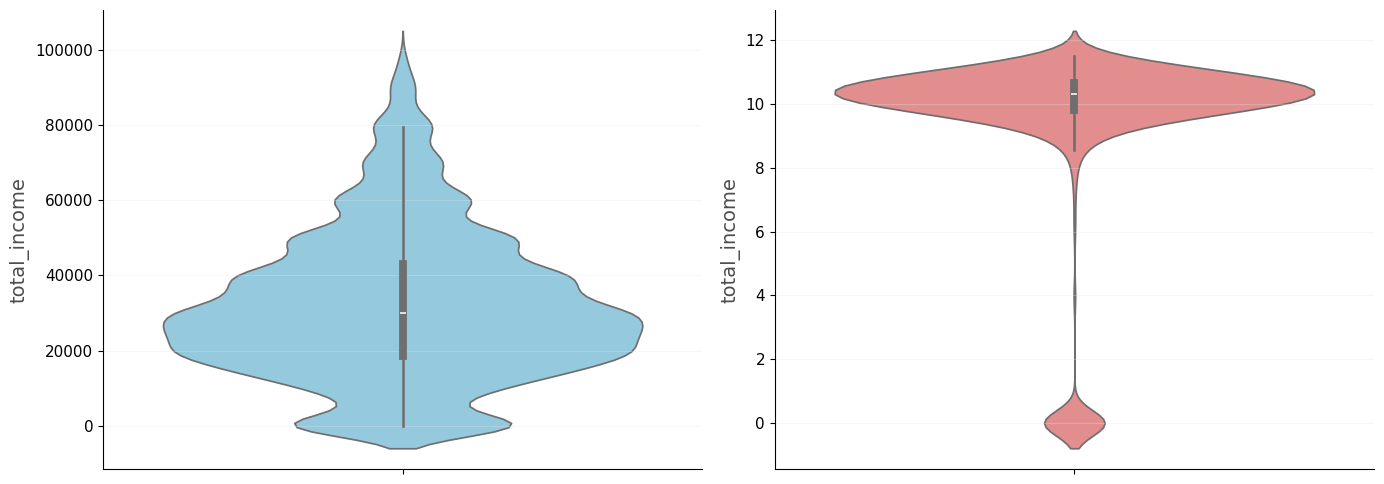

In [219]:
wages_original = panel['total_income'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.violinplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.violinplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

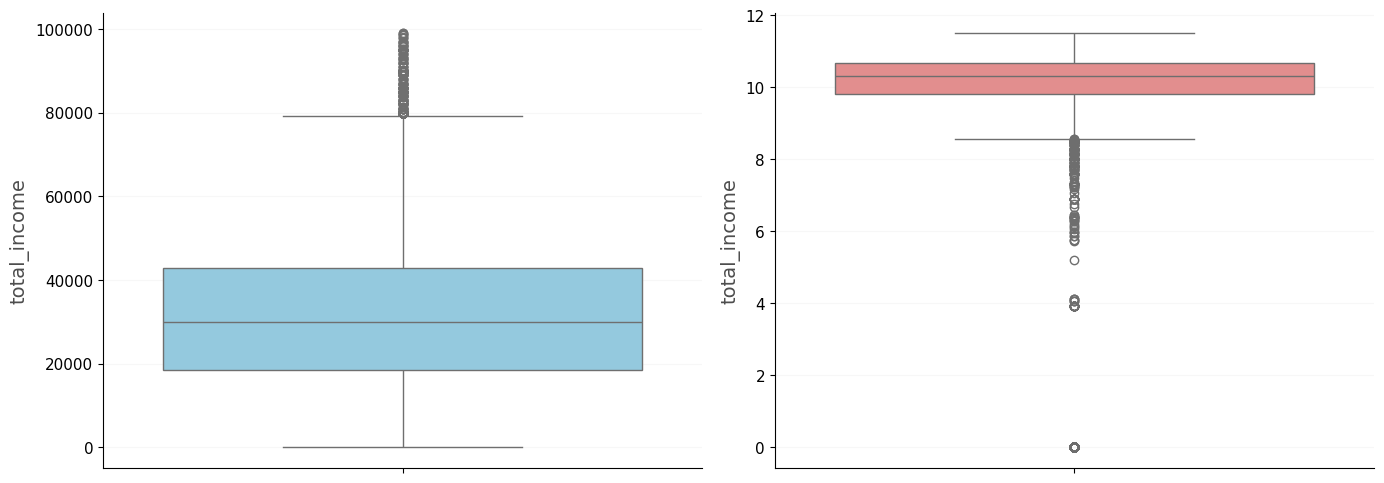

In [220]:
wages_original = panel['total_income'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.boxplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.boxplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

In [221]:
model1 = PanelOLS.from_formula('total_income ~ has_disablity + EntityEffects', data=panel_2019_2020).fit()#.fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model1.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:           total_income   R-squared:                        0.0004
Estimator:                   PanelOLS   R-squared (Between):             -0.0047
No. Observations:                3682   R-squared (Within):               0.0004
Date:                Wed, Apr 29 2026   R-squared (Overall):             -0.0047
Time:                        16:46:28   Log-likelihood                -3.749e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      0.5862
Entities:                        2293   P-value                           0.4440
Avg Obs:                       1.6058   Distribution:                  F(1,1388)
Min Obs:                       1.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             0.5862
                            

In [222]:
model2 = PanelOLS.from_formula('np.log1p(total_income) ~ has_disablity + EntityEffects', data=panel_2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model2.summary)

                            PanelOLS Estimation Summary                             
Dep. Variable:     np.log1p(total_income)   R-squared:                     4.279e-05
Estimator:                       PanelOLS   R-squared (Between):             -0.0010
No. Observations:                    3682   R-squared (Within):            4.279e-05
Date:                    Wed, Apr 29 2026   R-squared (Overall):             -0.0010
Time:                            16:46:29   Log-likelihood                   -5896.4
Cov. Estimator:                 Clustered                                           
                                            F-statistic:                      0.0594
Entities:                            2293   P-value                           0.8075
Avg Obs:                           1.6058   Distribution:                  F(1,1388)
Min Obs:                           1.0000                                           
Max Obs:                           2.0000   F-statistic (robust):

In [223]:
panel_2014_2024 = (
    panel
        #.filter(~pl.col('idind').is_in(ids_to_exclude_0 + ids_to_exclude_1))
        #.filter(~pl.col('idind').is_in(alike_matched.implode()))
        .filter(
            (pl.col('period_relevance') > -5) & (pl.col('period_relevance') < 5)
        )
        # .filter(pl.col('year').is_in([2019, 2020]))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
).to_pandas()
panel_2014_2024_dta = panel_2014_2024.set_index(['idind', 'year'])
panel_2014_2024_dta

recieves_pension  recieves_pension_30days  amount_pension  \
idind   year                                                                    
29.0    2017-01-01                 0                        0             0.0   
        2020-01-01                 0                        0             0.0   
        2021-01-01                 1                        1         11300.0   
180.0   2015-01-01                 0                        0             0.0   
        2020-01-01                 0                        0             0.0   
...                              ...                      ...             ...   
60467.0 2022-01-01                 0                        0             0.0   
60473.0 2020-01-01                 0                        0             0.0   
        2021-01-01                 0                        0             0.0   
60474.0 2020-01-01                 1                        1         15600.0   
        2021-01-01                 1                        1         16200.0   

                    iea_income  total_income  amount_unemp_benefits  wage_j1  \
idind   year                                                                   
29.0    2017-01-01         0.0           0.0                    0.0      0.0   
        2020-01-01         0.0       43000.0                    0.0  43000.0   
        2021-01-01         0.0           0.0                    0.0      0.0   
180.0   2015-01-01      3000.0       21000.0                    0.0  10000.0   
        2020-01-01         0.0       32000.0                    0.0  25000.0   
...                        ...           ...                    ...      ...   
60467.0 2022-01-01         0.0       38000.0                    0.0  37000.0   
60473.0 2020-01-01         0.0       40000.0                    0.0  40000.0   
        2021-01-01         0.0       55000.0                    0.0  35000.0   
60474.0 2020-01-01         0.0       15600.0                    0.0      0.0   
        2021-01-01         0.0       31200.0                    0.0  14000.0   

                    wage_j2  income_decrease_bc_covid  \
idind   year                                            
29.0    2017-01-01      0.0                         0   
        2020-01-01      0.0                         1   
        2021-01-01      0.0                         0   
180.0   2015-01-01   8000.0                         0   
        2020-01-01   7000.0                         0   
...                     ...                       ...   
60467.0 2022-01-01      0.0                         0   
60473.0 2020-01-01      0.0                         1   
        2021-01-01      0.0                         0   
60474.0 2020-01-01      0.0                         0   
        2021-01-01      0.0                         0   

                                  work_status  ...  educ_level_school_or_less  \
idind   year                                   ...                              
29.0    2017-01-01        You are not working  ...                          0   
        2020-01-01  You are currently working  ...                          0   
        2021-01-01  You are currently working  ...                          0   
180.0   2015-01-01  You are currently working  ...                          0   
        2020-01-01  You are currently working  ...                          0   
...                                       ...  ...                        ...   
60467.0 2022-01-01  You are currently working  ...                          0   
60473.0 2020-01-01  You are currently working  ...                          0   
        2021-01-01  You are currently working  ...                          0   
60474.0 2020-01-01  You are currently working  ...                          0   
        2021-01-01  You are currently working  ...                          0   

                    educ_level_university  is_married  period_relevance  \
idind   year                                          

In [224]:
event_study_terms = []
for p in sorted(panel_2014_2024_dta['period_relevance'].unique()):
    if p != 0:  # Exclude reference period
        col_name = f'rel_period_{p}_treated'
        # Create interaction: (relative_period == p) * treatment
        panel_2014_2024_dta[col_name] = ((panel_2014_2024_dta['period_relevance'].values == p) & (panel_2014_2024_dta['has_disability'].values == 1)).astype(int)
        event_study_terms.append(col_name)

X_event = panel_2014_2024_dta[event_study_terms]
#y_event = np.log1p(panel_2014_2024_dta['wages'])
y_event = panel_2014_2024_dta['total_income']

event_study_model = PanelOLS(y_event, X_event, entity_effects=True, check_rank=True).fit(cov_type='clustered', cluster_entity=True)
print(event_study_model.summary)

wald_test_for_period_insignificance(event_study_model)

                          PanelOLS Estimation Summary                           
Dep. Variable:           total_income   R-squared:                        0.0029
Estimator:                   PanelOLS   R-squared (Between):              0.0001
No. Observations:               12451   R-squared (Within):               0.0029
Date:                Wed, Apr 29 2026   R-squared (Overall):              0.0002
Time:                        16:46:30   Log-likelihood                -1.346e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3.7276
Entities:                        2312   P-value                           0.0002
Avg Obs:                       5.3854   Distribution:                 F(8,10131)
Min Obs:                       1.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             6.3772
                            

In [225]:
print(calculate_vif(X_event))

                 feature  VIF
0  rel_period_-4_treated  1.0
1  rel_period_-3_treated  1.0
2  rel_period_-2_treated  1.0
3  rel_period_-1_treated  1.0
4   rel_period_1_treated  1.0
5   rel_period_2_treated  1.0
6   rel_period_3_treated  1.0
7   rel_period_4_treated  1.0


# wages model

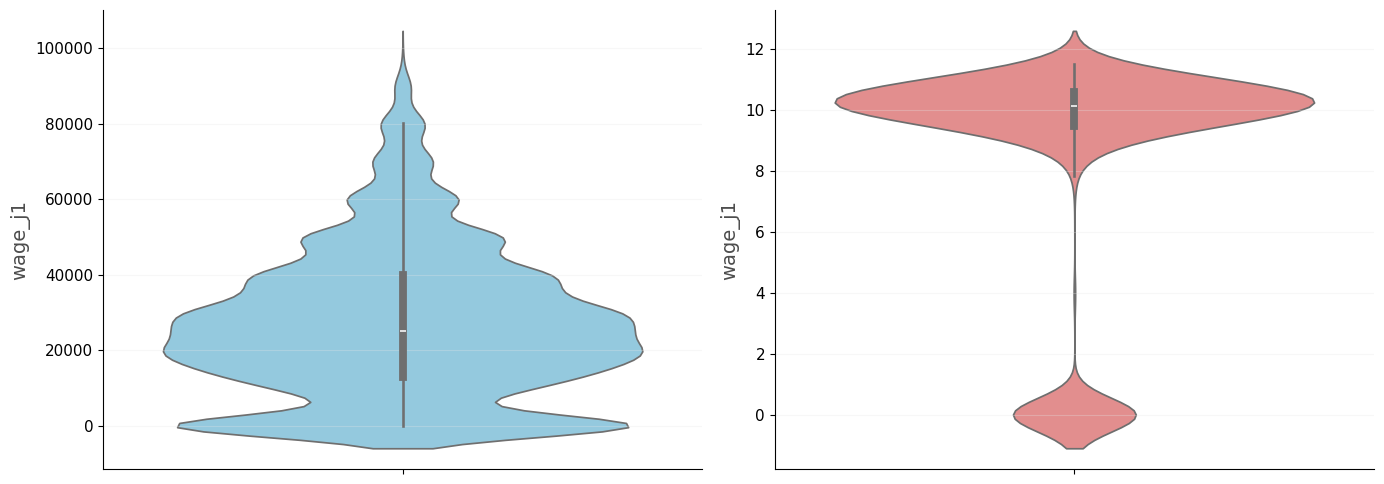

In [226]:
wages_original = panel['wage_j1'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.violinplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.violinplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

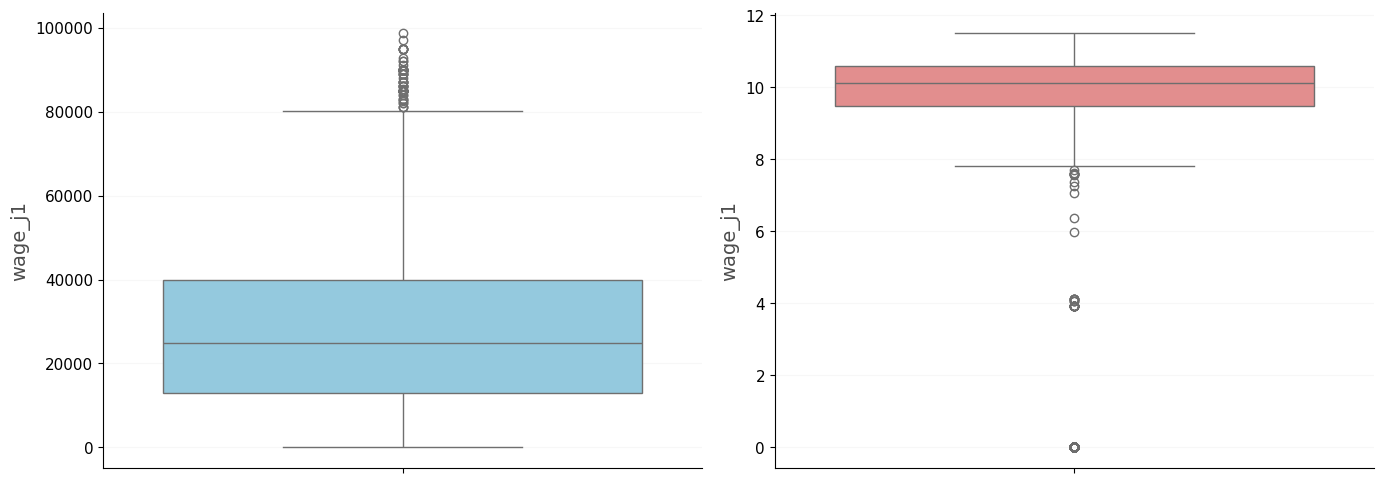

In [227]:
wages_original = panel['wage_j1'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.boxplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.boxplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

In [228]:
model3 = PanelOLS.from_formula('wage_j1 ~ has_disablity + EntityEffects', data=panel_2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model3.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                wage_j1   R-squared:                        0.0030
Estimator:                   PanelOLS   R-squared (Between):             -0.0122
No. Observations:                3682   R-squared (Within):               0.0030
Date:                Wed, Apr 29 2026   R-squared (Overall):             -0.0119
Time:                        16:46:34   Log-likelihood                -3.755e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      4.2327
Entities:                        2293   P-value                           0.0398
Avg Obs:                       1.6058   Distribution:                  F(1,1388)
Min Obs:                       1.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             5.9824
                            

In [229]:
-1.088e+04

-10880.0

In [230]:
model4 = PanelOLS.from_formula('np.log1p(wage_j1) ~ has_disablity + EntityEffects', data=panel_2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model4.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:      np.log1p(wage_j1)   R-squared:                        0.0049
Estimator:                   PanelOLS   R-squared (Between):             -0.0166
No. Observations:                3682   R-squared (Within):               0.0049
Date:                Wed, Apr 29 2026   R-squared (Overall):             -0.0168
Time:                        16:46:36   Log-likelihood                   -7419.6
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      6.7989
Entities:                        2293   P-value                           0.0092
Avg Obs:                       1.6058   Distribution:                  F(1,1388)
Min Obs:                       1.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             5.0610
                            

In [231]:
event_study_terms = []
for p in sorted(panel_2014_2024['period_relevance'].unique()):
    if p != 0:  # Exclude reference period
        col_name = f'rel_period_{p}_treated'
        # Create interaction: (relative_period == p) * treatment
        panel_2014_2024_dta[col_name] = ((panel_2014_2024['period_relevance'].values == p) & (panel_2014_2024['has_disability'].values == 1)).astype(int)
        event_study_terms.append(col_name)

X_event = panel_2014_2024_dta[event_study_terms]
#y_event = np.log1p(panel_2014_2024_dta['wages'])
y_event = panel_2014_2024_dta['wage_j1']

event_study_model = PanelOLS(y_event, X_event, entity_effects=True, time_effects=False, check_rank=False).fit(cov_type='clustered', cluster_entity=True)
print(event_study_model.summary)

wald_test_for_period_insignificance(event_study_model)

                          PanelOLS Estimation Summary                           
Dep. Variable:                wage_j1   R-squared:                       -4.7165
Estimator:                   PanelOLS   R-squared (Between):             -3.0674
No. Observations:               12451   R-squared (Within):              -0.3173
Date:                Wed, Apr 29 2026   R-squared (Overall):             -2.1512
Time:                        16:46:37   Log-likelihood                -1.451e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                     -1194.2
Entities:                        2312   P-value                           1.0000
Avg Obs:                       5.3854   Distribution:                 F(7,10132)
Min Obs:                       1.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             7.1685
                            

# benefit model

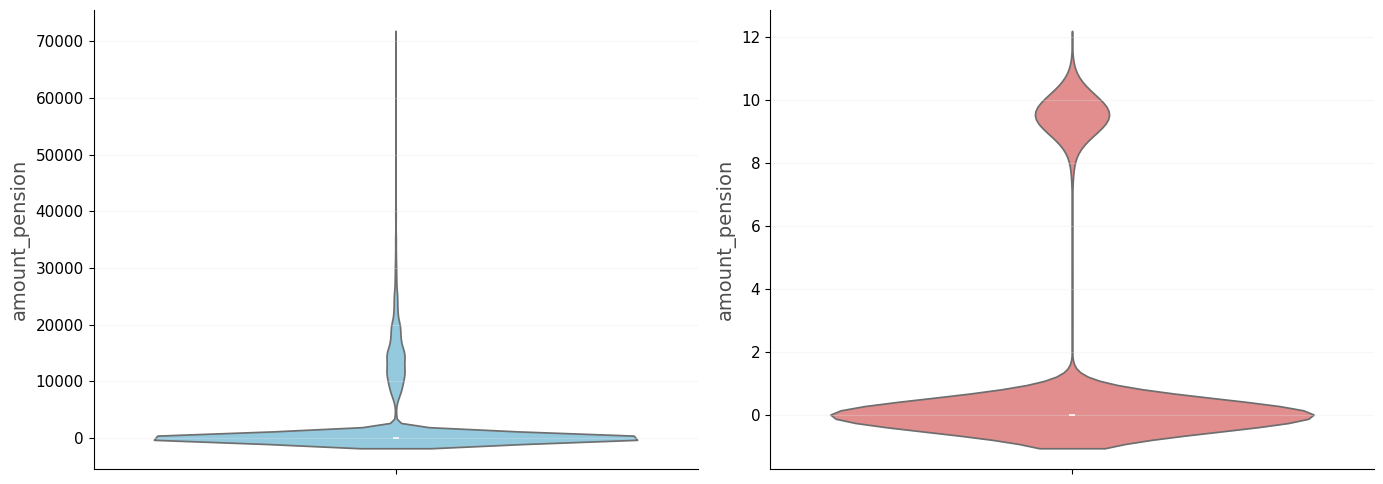

In [232]:
wages_original = panel['amount_pension'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.violinplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.violinplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

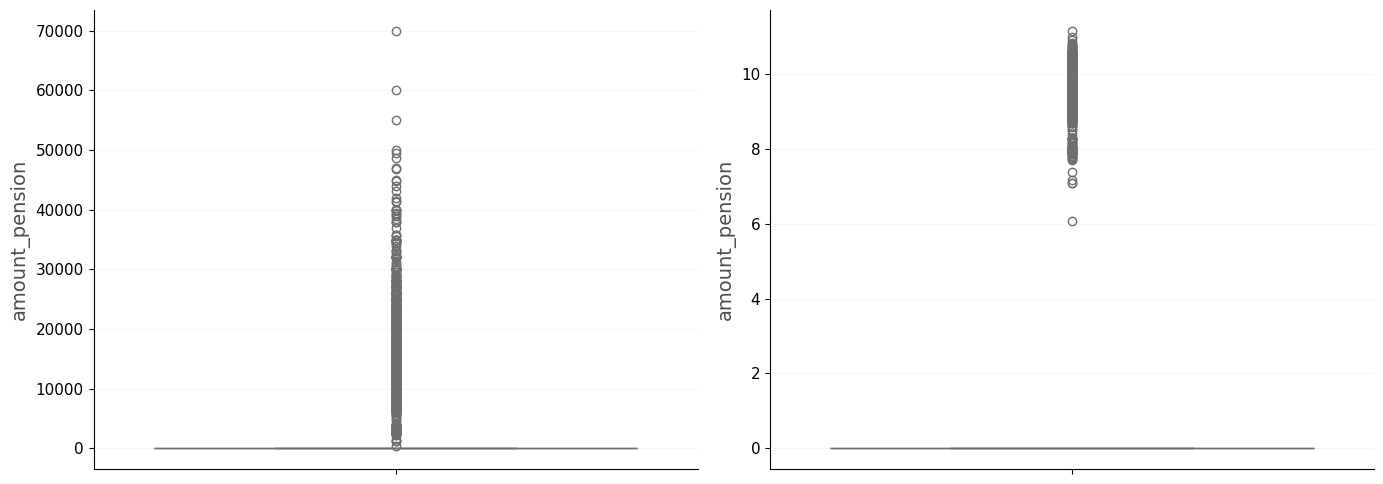

In [233]:
wages_original = panel['amount_pension'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.boxplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.boxplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

In [234]:
model5 = PanelOLS.from_formula('amount_pension ~ has_disablity + EntityEffects', data=panel_2019_2020).fit()#.fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model5.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:         amount_pension   R-squared:                        0.0367
Estimator:                   PanelOLS   R-squared (Between):              0.0567
No. Observations:                3682   R-squared (Within):               0.0367
Date:                Wed, Apr 29 2026   R-squared (Overall):              0.0572
Time:                        16:46:39   Log-likelihood                -3.075e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      52.939
Entities:                        2293   P-value                           0.0000
Avg Obs:                       1.6058   Distribution:                  F(1,1388)
Min Obs:                       1.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             52.939
                            

In [235]:
model6 = PanelOLS.from_formula('np.log1p(amount_pension) ~ has_disablity + EntityEffects', data=panel_2019_2020).fit()#.fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model6.summary)

                             PanelOLS Estimation Summary                              
Dep. Variable:     np.log1p(amount_pension)   R-squared:                        0.0660
Estimator:                         PanelOLS   R-squared (Between):              0.0770
No. Observations:                      3682   R-squared (Within):               0.0660
Date:                      Wed, Apr 29 2026   R-squared (Overall):              0.0814
Time:                              16:46:39   Log-likelihood                   -3177.7
Cov. Estimator:                  Unadjusted                                           
                                              F-statistic:                      98.072
Entities:                              2293   P-value                           0.0000
Avg Obs:                             1.6058   Distribution:                  F(1,1388)
Min Obs:                             1.0000                                           
Max Obs:                             2.0000

In [ ]:
print(model6.summary)

In [236]:
event_study_terms = []
for p in sorted(panel_2014_2024['period_relevance'].unique()):
    if p != 0:  # Exclude reference period
        col_name = f'rel_period_{p}_treated'
        # Create interaction: (relative_period == p) * treatment
        panel_2014_2024_dta[col_name] = ((panel_2014_2024['period_relevance'].values == p) & (panel_2014_2024['has_disability'].values == 1)).astype(int)
        event_study_terms.append(col_name)

X_event = panel_2014_2024_dta[event_study_terms]
#y_event = np.log1p(panel_2014_2024_dta['wages'])
y_event = panel_2014_2024_dta['amount_pension']

event_study_model = PanelOLS(y_event, X_event, entity_effects=True, time_effects=False, check_rank=False).fit(cov_type='clustered', cluster_entity=True)
print(event_study_model.summary)

wald_test_for_period_insignificance(event_study_model)

                          PanelOLS Estimation Summary                           
Dep. Variable:         amount_pension   R-squared:                       -0.9943
Estimator:                   PanelOLS   R-squared (Between):             -0.0933
No. Observations:               12451   R-squared (Within):              -0.0374
Date:                Wed, Apr 29 2026   R-squared (Overall):             -0.0785
Time:                        16:46:40   Log-likelihood                -1.173e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                     -721.63
Entities:                        2312   P-value                           1.0000
Avg Obs:                       5.3854   Distribution:                 F(7,10132)
Min Obs:                       1.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             16.772
                            

In [237]:
print(compare({
    'model 1':model1, 
    "model 1 log": model2, 
    "model 2": model3, 
    'model 2 log':model4,
    "model 3": model5, 
    'model 3 log':model6
}, stars=True))

                                                                     Model Comparison                                                                     
                                 model 1                model 1 log          model 2           model 2 log            model 3                  model 3 log
----------------------------------------------------------------------------------------------------------------------------------------------------------
Dep. Variable               total_income     np.log1p(total_income)          wage_j1     np.log1p(wage_j1)     amount_pension     np.log1p(amount_pension)
Estimator                       PanelOLS                   PanelOLS         PanelOLS              PanelOLS           PanelOLS                     PanelOLS
No. Observations                    3682                       3682             3682                  3682               3682                         3682
Cov. Est.                     Unadjusted                  Clustered   

# PSM

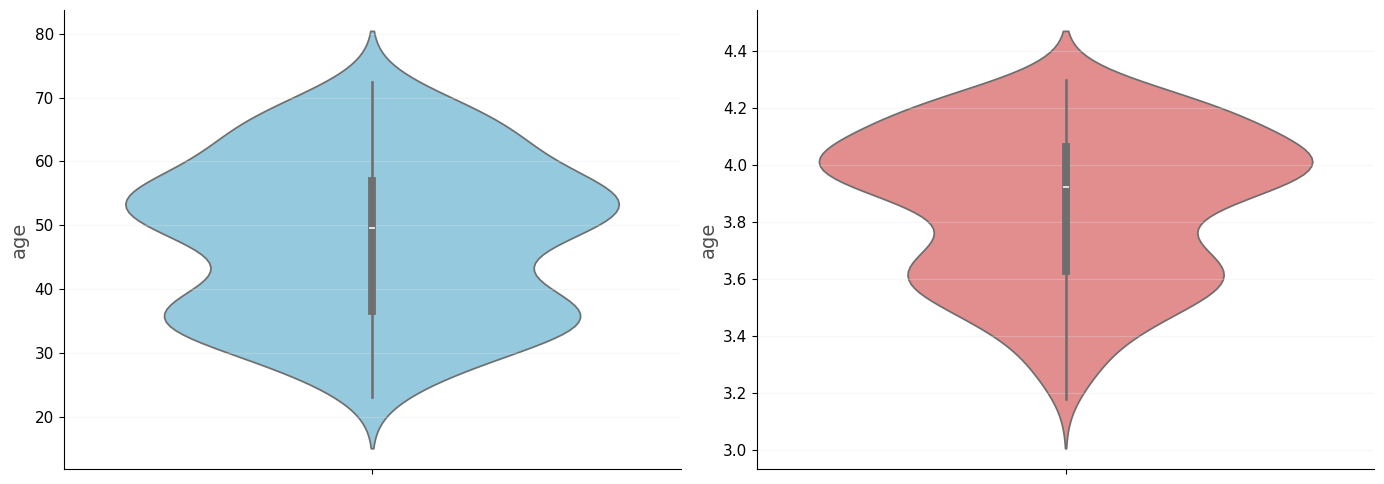

In [255]:
wages_original = panel.filter(pl.col('has_disablity') == 1)['age'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.violinplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.violinplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

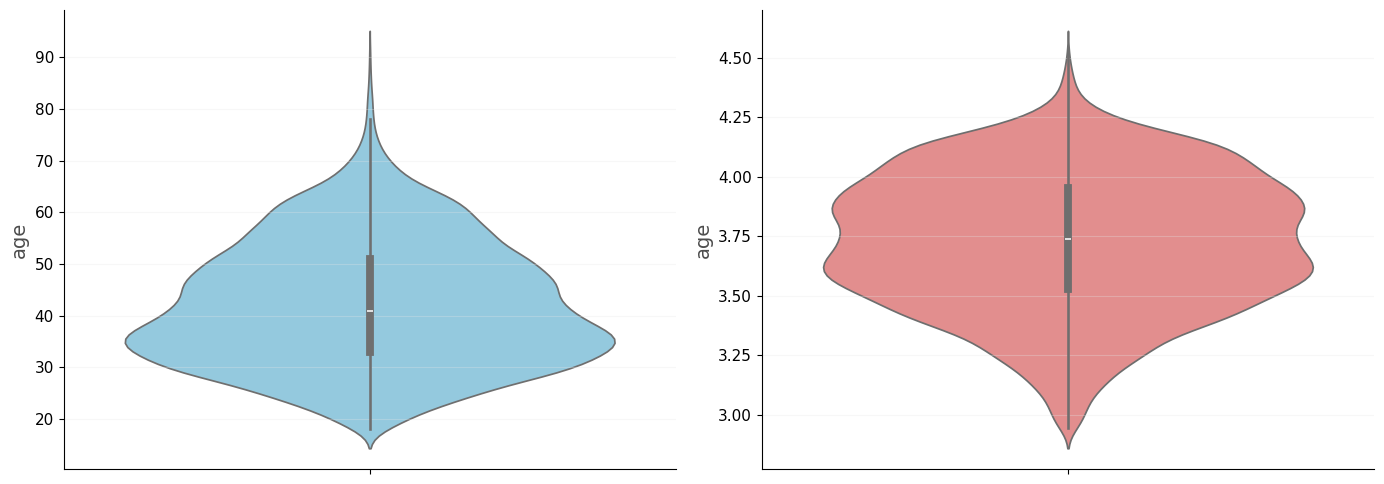

In [256]:
wages_original = panel.filter(pl.col('has_disablity') == 0)['age'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.violinplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.violinplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

# Pension models

In [238]:
panel_2019_2020

recieves_pension  recieves_pension_30days  amount_pension  \
idind   year                                                                    
29.0    2020-01-01                 0                        0             0.0   
180.0   2020-01-01                 0                        0             0.0   
434.0   2019-01-01                 0                        0             0.0   
        2020-01-01                 0                        0             0.0   
454.0   2020-01-01                 0                        0             0.0   
...                              ...                      ...             ...   
60464.0 2020-01-01                 0                        0             0.0   
60465.0 2020-01-01                 1                        1         13500.0   
60467.0 2020-01-01                 0                        0             0.0   
60473.0 2020-01-01                 0                        0             0.0   
60474.0 2020-01-01                 1                        1         15600.0   

                    iea_income  total_income  amount_unemp_benefits  wage_j1  \
idind   year                                                                   
29.0    2020-01-01         0.0       43000.0                    0.0  43000.0   
180.0   2020-01-01         0.0       32000.0                    0.0  25000.0   
434.0   2019-01-01         0.0       25000.0                    0.0  25000.0   
        2020-01-01         0.0       20000.0                    0.0  10000.0   
454.0   2020-01-01         0.0       40500.0                    0.0  10500.0   
...                        ...           ...                    ...      ...   
60464.0 2020-01-01         0.0       22000.0                    0.0  22000.0   
60465.0 2020-01-01         0.0       33500.0                    0.0  20000.0   
60467.0 2020-01-01         0.0       26600.0                    0.0  26000.0   
60473.0 2020-01-01         0.0       40000.0                    0.0  40000.0   
60474.0 2020-01-01         0.0       15600.0                    0.0      0.0   

                    wage_j2  income_decrease_bc_covid  \
idind   year                                            
29.0    2020-01-01      0.0                         1   
180.0   2020-01-01   7000.0                         0   
434.0   2019-01-01      0.0                         0   
        2020-01-01      0.0                         0   
454.0   2020-01-01      0.0                         0   
...                     ...                       ...   
60464.0 2020-01-01      0.0                         0   
60465.0 2020-01-01      0.0                         0   
60467.0 2020-01-01      0.0                         0   
60473.0 2020-01-01      0.0                         1   
60474.0 2020-01-01      0.0                         0   

                                                          work_status  ...  \
idind   year                                                           ...   
29.0    2020-01-01                          You are currently working  ...   
180.0   2020-01-01                          You are currently working  ...   
434.0   2019-01-01                          You are currently working  ...   
        2020-01-01                          You are currently working  ...   
454.0   2020-01-01  You are on paid leave: maternity leave or taki...  ...   
...                                                               ...  ...   
60464.0 2020-01-01                          You are currently working  ...   
60465.0 2020-01-01                          You are currently working  ...   
60467.0 2020-01-01  You are on paid leave: maternity leave or taki...  ...   
60473.0 2020-01-01                          You are currently working  ...   
60474.0 2020-01-01                          You are currently working  ...   

                    educ_level_school_or_less  educ_level_university  \
idind   year                                                           
29.0    2020-01-01      

In [239]:
model7 = PanelOLS.from_formula('np.log1p(wages) ~ has_disablity + is_retired + EntityEffects', data=panel_2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model7.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:        np.log1p(wages)   R-squared:                        0.0061
Estimator:                   PanelOLS   R-squared (Between):             -0.0363
No. Observations:                3682   R-squared (Within):               0.0061
Date:                Wed, Apr 29 2026   R-squared (Overall):             -0.0358
Time:                        16:46:45   Log-likelihood                   -7423.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      4.2435
Entities:                        2293   P-value                           0.0145
Avg Obs:                       1.6058   Distribution:                  F(2,1387)
Min Obs:                       1.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             3.9658
                            

In [240]:
model7 = PanelOLS.from_formula('np.log1p(wages) ~ has_disablity + EntityEffects', data=panel_2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model7.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:        np.log1p(wages)   R-squared:                        0.0049
Estimator:                   PanelOLS   R-squared (Between):             -0.0169
No. Observations:                3682   R-squared (Within):               0.0049
Date:                Wed, Apr 29 2026   R-squared (Overall):             -0.0171
Time:                        16:46:46   Log-likelihood                   -7426.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      6.7748
Entities:                        2293   P-value                           0.0093
Avg Obs:                       1.6058   Distribution:                  F(1,1388)
Min Obs:                       1.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             5.0610
                            

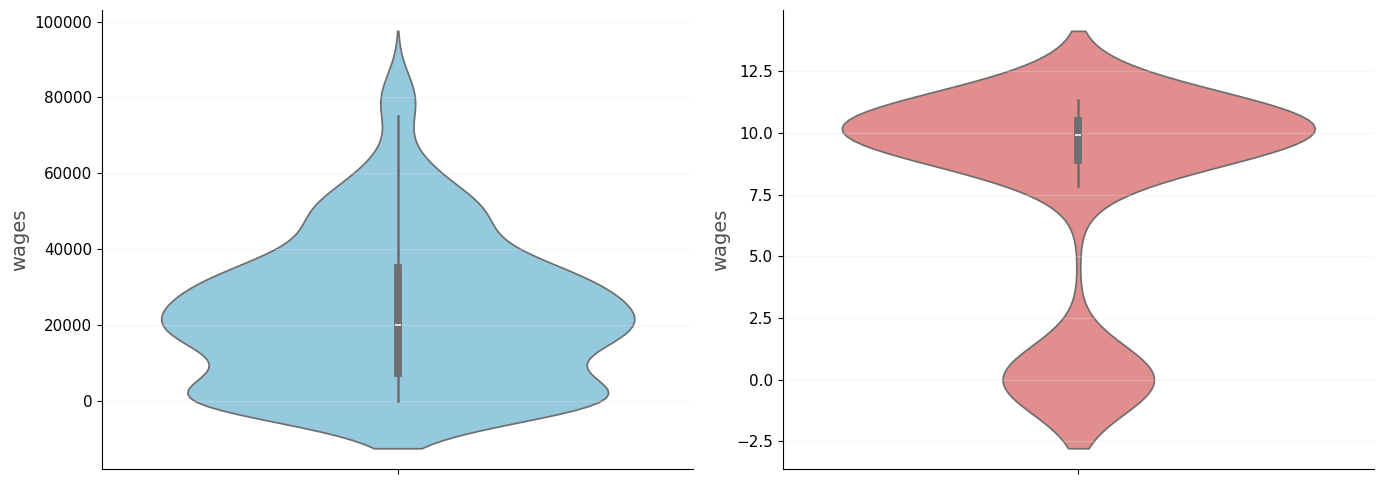

In [241]:
wages_original = panel.filter(pl.col('has_disablity') == 1)['wages'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.violinplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.violinplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

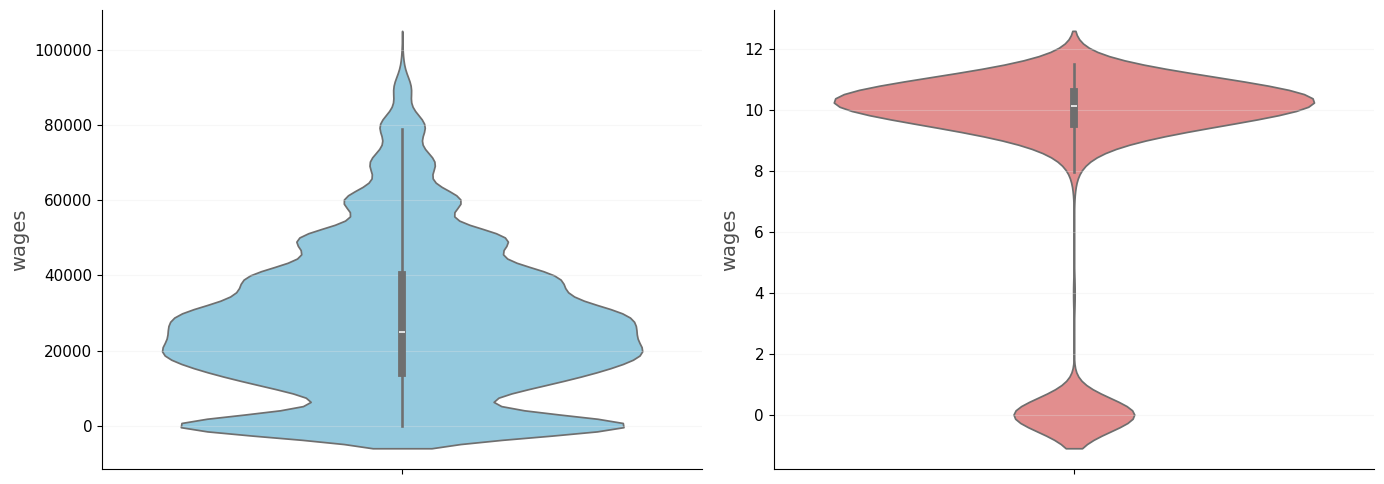

In [242]:
wages_original = panel.filter(pl.col('has_disablity') == 0)['wages'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.violinplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.violinplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

In [243]:
model8 = PanelOLS.from_formula('wages ~ has_disablity + EntityEffects', data=panel_2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model8.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  wages   R-squared:                        0.0029
Estimator:                   PanelOLS   R-squared (Between):             -0.0120
No. Observations:                3682   R-squared (Within):               0.0029
Date:                Wed, Apr 29 2026   R-squared (Overall):             -0.0117
Time:                        16:46:48   Log-likelihood                -3.764e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      4.0112
Entities:                        2293   P-value                           0.0454
Avg Obs:                       1.6058   Distribution:                  F(1,1388)
Min Obs:                       1.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             5.9824
                            

In [257]:
print(model8.summary.as_latex())

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &       wages        & \textbf{  R-squared:         }   &      0.0029      \\
\textbf{Estimator:}        &      PanelOLS      & \textbf{  R-squared (Between):}  &     -0.0120      \\
\textbf{No. Observations:} &        3682        & \textbf{  R-squared (Within):}   &      0.0029      \\
\textbf{Date:}             &  Wed, Apr 29 2026  & \textbf{  R-squared (Overall):}  &     -0.0117      \\
\textbf{Time:}             &      16:46:48      & \textbf{  Log-likelihood     }   &    -3.764e+04    \\
\textbf{Cov. Estimator:}   &     Clustered      & \textbf{                     }   &                  \\
\textbf{}                  &                    & \textbf{  F-statistic:       }   &      4.0112      \\
\textbf{Entities:}         &        2293        & \textbf{  P-value            }   &      0.0454      \\
\textbf{Avg Obs:}          &       1.6058       & \textbf{  Distribution:      }   &    F(1,1388)     \\
\textbf{M

In [244]:
model9 = PanelOLS.from_formula('wages ~ has_disablity + is_retired +  EntityEffects', data=panel_2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model9.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  wages   R-squared:                        0.0038
Estimator:                   PanelOLS   R-squared (Between):             -0.0241
No. Observations:                3682   R-squared (Within):               0.0038
Date:                Wed, Apr 29 2026   R-squared (Overall):             -0.0234
Time:                        16:46:48   Log-likelihood                -3.764e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2.6791
Entities:                        2293   P-value                           0.0690
Avg Obs:                       1.6058   Distribution:                  F(2,1387)
Min Obs:                       1.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             5.1020
                            

In [245]:
model10 = PanelOLS.from_formula('wages ~ has_disablity +  EntityEffects', data=panel_2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model10.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  wages   R-squared:                        0.0029
Estimator:                   PanelOLS   R-squared (Between):             -0.0120
No. Observations:                3682   R-squared (Within):               0.0029
Date:                Wed, Apr 29 2026   R-squared (Overall):             -0.0117
Time:                        16:46:49   Log-likelihood                -3.764e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      4.0112
Entities:                        2293   P-value                           0.0454
Avg Obs:                       1.6058   Distribution:                  F(1,1388)
Min Obs:                       1.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             5.9824
                            

In [246]:
did_data.columns

Index(['idind', 'year', 'recieves_pension', 'recieves_pension_30days',
       'amount_pension', 'iea_income', 'total_income', 'amount_unemp_benefits',
       'wage_j1', 'wage_j2', 'income_decrease_bc_covid', 'work_status',
       'hearing_disability', 'eye_disability', 'spinal_disability',
       'neuro_disability', 'disability_class_first_group',
       'disability_class_second_group', 'disability_class_third_group',
       'has_disability', 'registred_as_disabled', 'month', 'wave', 'region',
       'habitat', 'psu', 'age', 'educ', 'marst', 'gender', 'is_employed',
       'has_disablity', 'wages', 'educ_level', 'is_married',
       'period_relevance', 'is_town', 'is_female', 'has_disability_common',
       'male_retiered', 'female_retiered', 'is_retired', 'period'],
      dtype='object')

In [247]:
did_data = panel_2019_2020.reset_index()
did_data['period'] = np.where(did_data['year'] == '2020-01-01', 1, 0)
did_data

,idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,...,educ_level_university,is_married,period_relevance,is_town,is_female,has_disability_common,male_retiered,female_retiered,is_retired,period
0,29.0,2020-01-01,0,0,0.0,0.0,43000.0,0.0,43000.0,0.0,...,0,0,1,1,1,0,0,0,0,1
1,180.0,2020-01-01,0,0,0.0,0.0,32000.0,0.0,25000.0,7000.0,...,1,1,1,0,1,0,0,0,0,1
2,434.0,2019-01-01,0,0,0.0,0.0,25000.0,0.0,25000.0,0.0,...,1,1,0,1,1,0,0,0,0,0
3,434.0,2020-01-01,0,0,0.0,0.0,20000.0,0.0,10000.0,0.0,...,1,1,1,1,1,0,0,0,0,1
4,454.0,2020-01-01,0,0,0.0,0.0,40500.0,0.0,10500.0,0.0,...,1,1,1,1,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3677,60464.0,2020-01-01,0,0,0.0,0.0,22000.0,0.0,22000.0,0.0,...,0,1,1,1,0,0,0,0,0,1
3678,60465.0,2020-01-01,1,1,13500.0,0.0,33500.0,0.0,20000.0,0.0,...,0,1,1,1,1,0,0,0,0,1
3679,60467.0,2020-01-01,0,0,0.0,0.0,26600.0,0.0,26000.0,0.0,...,1,0,1,1,1,0,0,0,0,1
3680,60473.0,2020-01-01,0,0,0.0,0.0,40000.0,0.0,40000.0,0.0,...,0,1,1,1,1,0,0,0,0,1


In [254]:
did_model = smf.ols('wages ~ has_disability * period', did_data).fit(cov_type='HC2')
print(did_model.summary2())

                        Results: Ordinary least squares
Model:                   OLS                  Adj. R-squared:         0.000     
Dependent Variable:      wages                AIC:                    82584.1108
Date:                    2026-04-29 16:49     BIC:                    82608.9557
No. Observations:        3682                 Log-Likelihood:         -41288.   
Df Model:                3                    F-statistic:            1.666     
Df Residuals:            3678                 Prob (F-statistic):     0.172     
R-squared:               0.001                Scale:                  3.2204e+08
--------------------------------------------------------------------------------
                        Coef.     Std.Err.    z    P>|z|     [0.025     0.975]  
--------------------------------------------------------------------------------
Intercept             27033.3678  496.4549 54.4528 0.0000  26060.3341 28006.4014
has_disability        -5380.0344 3097.4000 -1.7370 0.